> 공식 문서: <https://langchain-ai.github.io/langgraph/tutorials/multi_agent/agent_supervisor/#research-agent>

### 1. Create worker agents

In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from langchain_core.tools import tool
from langchain_community.utilities import DuckDuckGoSearchAPIWrapper
from langchain_community.tools import DuckDuckGoSearchResults 

@tool
def get_web_search(query: str, search_period: str='w') -> str:
    """
    웹 검색을 수행하는 함수.

    Args:
        query (str): 검색어
        search_period (str): 검색 기간 (e.g., "w" for past week (default), "m" for past month, "y" for past year, "d" for past day)

    Returns:
        str: 검색 결과
    """
    wrapper = DuckDuckGoSearchAPIWrapper(
        time=search_period
    )

    print('\n----- WEB SEARCH -----')
    print(query)
    print(search_period)

    search = DuckDuckGoSearchResults(
        api_wrapper=wrapper,
        results_separator=';\n'
    )

    searched = search.invoke(query)
    
    for i, result in enumerate(searched.split(';\n')):
        print(f'{i+1}. {result}')
    
    return searched

In [3]:
from langgraph.prebuilt import create_react_agent

research_agent = create_react_agent(
    model="google_genai:gemini-3.1-flash-lite",
    tools=[get_web_search],
    prompt=(
        "당신은 리서치 에이전트입니다.\n\n"
        "지시사항:\n"
        "- 리서치 관련 작업만 수행하고, 수학 계산은 절대 하지 마세요.\n"
        "- 작업을 완료한 후에는 감독관(supervisor)에게 직접 응답하세요.\n"
        "- 작업 결과만 응답하고, 다른 텍스트는 포함하지 마세요."
    ),
    name="research_agent",
)

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_8432\2853663219.py:3: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  research_agent = create_react_agent(


In [4]:
from langchain_core.messages import convert_to_messages


def pretty_print_message(message, indent=False):
    pretty_message = message.pretty_repr(html=True)
    if not indent:
        print(pretty_message)
        return

    indented = "\n".join("\t" + c for c in pretty_message.split("\n"))
    print(indented)


def pretty_print_messages(update, last_message=False):
    is_subgraph = False
    if isinstance(update, tuple):
        ns, update = update
        # skip parent graph updates in the printouts
        if len(ns) == 0:
            return

        graph_id = ns[-1].split(":")[0]
        print(f"Update from subgraph {graph_id}:")
        print("\n")
        is_subgraph = True

    for node_name, node_update in update.items():
        update_label = f"Update from node {node_name}:"
        if is_subgraph:
            update_label = "\t" + update_label
        
        print(update_label)
        print("\n")

        messages = convert_to_messages(node_update["messages"])
        if last_message:
            messages = messages[-1:]

        for m in messages:
            pretty_print_message(m, indent=is_subgraph)
        print("\n")

In [5]:
for chunk in research_agent.stream(
    {"messages": [{"role": "user", "content": "부산시 시장은 누구일까?"}]}
):
    pretty_print_messages(chunk)

Update from node agent:


================================== Ai Message ==================================
Name: research_agent

[]
Tool Calls:
  get_web_search (1c64e625-f314-4ca4-a151-ef84e75b285b)
 Call ID: 1c64e625-f314-4ca4-a151-ef84e75b285b
  Args:
    query: 부산광역시장



----- WEB SEARCH -----
부산광역시장
w
1. snippet: 부산광역시체육회 (회장 장인화)는 지난 6월 11일 부산광역시장 당선인을 초청해 「민선9기 부산광역시장 당선인 초청 부산체육인 간담회」를 개최하고 부산체육 발전 방향과 주요 현안을 논의했다., title: 민선9기 부산광역시장 당선인 초청...부산체육인 간담회 개최 - 한국생활체육뉴스, link: http://www.kstnews.co.kr/news/articleView.html?idxno=41204
2. snippet: 이후 부산광역시청, 해운대구청 등에서 근무하다가 행정안전부 본부에서 지방세정책과장, 교부세과장 등 과장급 (3급) 직위를 거쳐 서병수 부산광역시장 당시 부산광역시청 정책기획실장 (고공단 나급, 2급)으로 근무하였다., title: 변성완 - 나무위키, link: https://namu.wiki/w/변성완
3. snippet: 3선 도전에 실패한 박형준 부산광역시장이 조기 퇴임한다. 11일 부산시에 따르면 오는 26일 오후 부산광역시청 대강당에서 직원들이 참석한 가운데 박 시장의 퇴임식을 연다. 박 시장의 공식 임기 종료일은 이달 30일이지만 일찌감치 퇴임식을 치른 뒤 남은 임기 동안 연가를 사용할 것으로 전해졌다., title: 박형준 부산시장, 26일 조기 퇴임…전재수 시정 준비 배려, link: https://www.inews24.com/view/1975787
4. snippe

In [6]:
def add(a: float, b: float):
    """Add two numbers."""
    return a + b


def multiply(a: float, b: float):
    """Multiply two numbers."""
    return a * b


def divide(a: float, b: float):
    """Divide two numbers."""
    return a / b


math_agent = create_react_agent(
    model="google_genai:gemini-2.5-flash",
    tools=[add, multiply, divide],
    prompt=(
        "당신은 수학 에이전트입니다.\n\n"
        "지시사항:\n"
        "- 수학 관련 작업만 수행하세요.\n"
        "- 작업을 완료한 후에는 감독관(supervisor)에게 직접 응답하세요.\n"
        "- 작업 결과만 응답하고, 다른 텍스트는 포함하지 마세요."
    ),
    name="math_agent",
)

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_8432\2013410382.py:16: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  math_agent = create_react_agent(


In [7]:
for chunk in math_agent.stream(
    {"messages": [{"role": "user", "content": "(3 + 5) x 7은 얼마인가요?"}]}
):
    pretty_print_messages(chunk)

Update from node agent:


================================== Ai Message ==================================
Name: math_agent
Tool Calls:
  add (679b7cf4-e05d-4e3b-a8d5-03426c29f116)
 Call ID: 679b7cf4-e05d-4e3b-a8d5-03426c29f116
  Args:
    a: 3
    b: 5


Update from node tools:


================================= Tool Message =================================
Name: add

8.0


Update from node agent:


================================== Ai Message ==================================
Name: math_agent
Tool Calls:
  multiply (54223f66-32bb-4a1c-a3c5-d9d357aac753)
 Call ID: 54223f66-32bb-4a1c-a3c5-d9d357aac753
  Args:
    a: 8
    b: 7


Update from node tools:


================================= Tool Message =================================
Name: multiply

56.0


Update from node agent:


================================== Ai Message ==================================
Name: math_agent

[{'type': 'text', 'text': '56', 'extras': {'signature': 'Cp4BAQw51sefgVjUjgGRLdqfRnSYimjoREbS5FlYH9yed/8

### 2. Create supervisor with langgraph-supervisor

In [9]:
from langgraph_supervisor import create_supervisor # uv add langgraph-supervisor
from langchain.chat_models import init_chat_model

supervisor = create_supervisor(
    model=init_chat_model("google_genai:gemini-3.1-flash-lite"),
    agents=[research_agent, math_agent],
    prompt=(
        "당신은 두 에이전트를 관리하는 감독관입니다:\n"
        "- 리서치 에이전트. 리서치 관련 작업은 이 에이전트에게 할당하세요.\n"
        "- 수학 에이전트. 수학 관련 작업은 이 에이전트에게 할당하세요.\n"
        "한 번에 하나의 에이전트에게만 작업을 할당하고, 여러 에이전트를 병렬로 호출하지 마세요.\n"
        "어떤 작업도 직접 수행하지 마세요."
    ),
    add_handoff_back_messages=True,
    output_mode="full_history",
).compile()

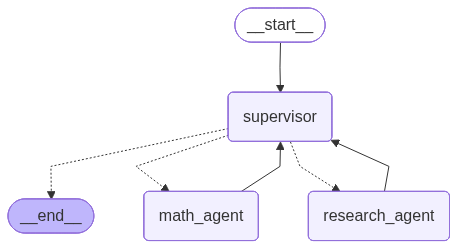

In [10]:
from IPython.display import display, Image

Image(supervisor.get_graph().draw_mermaid_png())

In [14]:
for chunk in supervisor.stream(
    {
        "messages": [
            {
                "role": "user",
                "content": "2025년 한국과 부산시의 GDP를 찾으세요. 부산시는 한국 GDP의 몇 퍼센트인가요?",
            }
        ]
    },
):
    pretty_print_messages(chunk, last_message=True)

final_message_history = chunk["supervisor"]["messages"]

Update from node supervisor:


================================= Tool Message =================================
Name: transfer_to_research_agent

Successfully transferred to research_agent



----- WEB SEARCH -----
2025년 한국 GDP 전망치
w
1. snippet: 3 days ago · 이날 한국은행은 올해 1분기 명목 GDP 성장률이 작년 동기대비 17.1%로 1995년 3분기 (19.2%) 이후 30년 6개월 만에 최고였다고 밝혔다., title: 씨티, 올해 명목 GDP 성장률 10.6→15.3%로 전망치 상향, link: https://www.msn.com/ko-kr/money/경제/씨티-올해-명목-gdp-성장률-10-6-15-3-로-전망치-상향/ar-AA25a4Mq
2. snippet: 3 days ago · 한국씨티은행 김진욱 이코노미스트는 공개한 보고서를 통해 올해 명목 GDP 성장률을 기존 10.6%에서 이같이 상향 조정했는데, 이번 전망치는 1995년 이후 가장 높은 수준입니다. 반면 올해 실질 GDP 성장률 전망치는 기존과 같은 3.0%를 유지했습니다., title: 씨티, 올해 명목 GDP 성장률 10.6→15.3%로 전망치 상향 - SBS Biz, link: https://biz.sbs.co.kr/article/20000315460
3. snippet: 3 days ago · (서울=연합뉴스) 이도흔 기자 = 한국씨티은행은 한국의 올해 명목 국내총생산 (GDP) 성장률 전망치를 15.3%로 상향한다고 9일 밝혔다. 한국씨티은행 김진욱 이코노미스트는 이날 공개한 보고서를 통해 올해 명목 GDP 성장률을 기존 10.6%에서 이같이 상향 조정했다., title: 씨티, 올해 명목 GDP 성장률 10.6→15.3%로 전망치 상향, link: https://www.yna.co